In [9]:
%matplotlib inline
# changed from %matplotlib notebook as graphs werent being plotted 

In [10]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq 
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

import os
import pickle
from matplotlib.ticker import MaxNLocator, ScalarFormatter, FormatStrFormatter
from matplotlib.ticker import LinearLocator
FIGSIZE = (4.5,3)
DPI = 300
N_TICKS = 3

In [11]:
from src.discrimalign import discrimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [12]:
from miRBench.dataset import list_datasets, get_dataset_df

In [13]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [14]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

# Optimization

### Simple model on miRNA alignments:

In [15]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [16]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch
# aligner.end_gap_score = 0

In [17]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

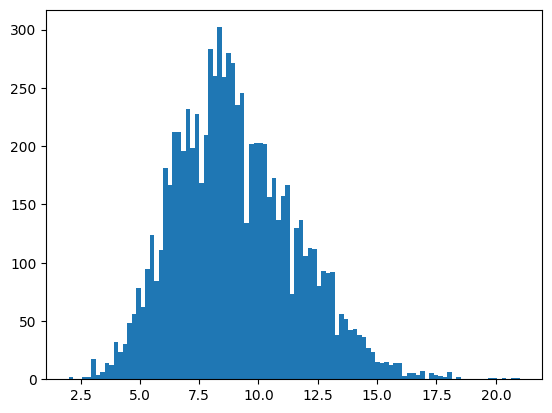

In [18]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [19]:
true_alpha = -9
## true_alpha = -np.median(scores)

In [20]:
logit_scores = logit_partial_scores(scores, true_alpha)

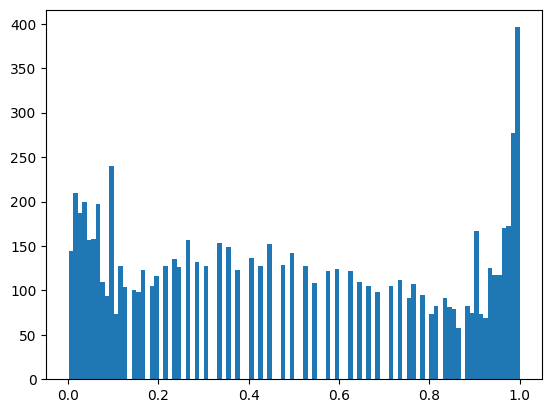

In [21]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

### Test Run

In [22]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
labels

array([False,  True,  True, ..., False,  True,  True], shape=(8193,))

In [23]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL) ## This is different 

Sum of log-logit scores: -10002.78024009512
True LogL: -3270.180240095122


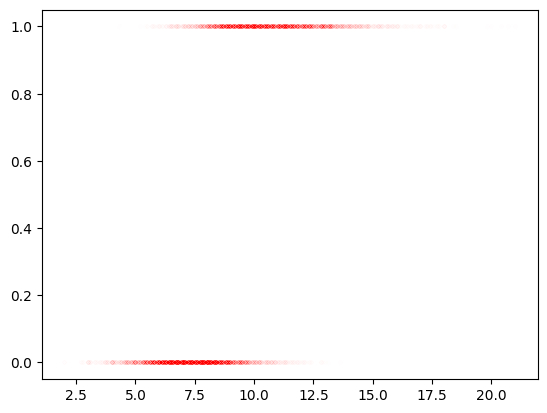

In [24]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

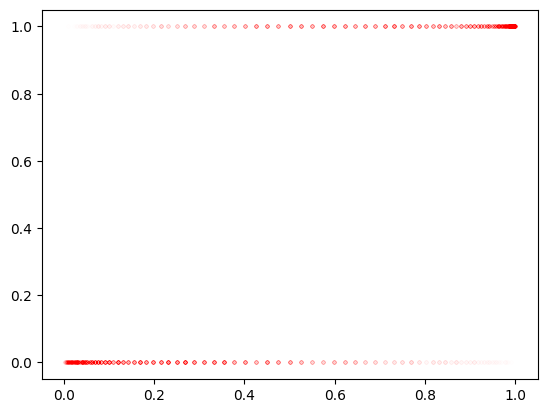

In [25]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [18]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [19]:
NITER = 50# original 50

In [ ]:
params = discrimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    verbose=True, max_iter=NITER,
                    stochastic_factor=None,
                    num_threads = 16)

In [ ]:
print(params['final_loglik'])

In [ ]:
print(params['final_loglik'])

-3282.062894589858


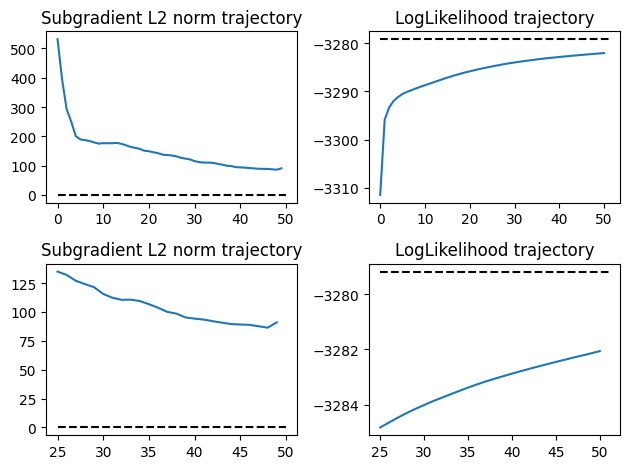

In [ ]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

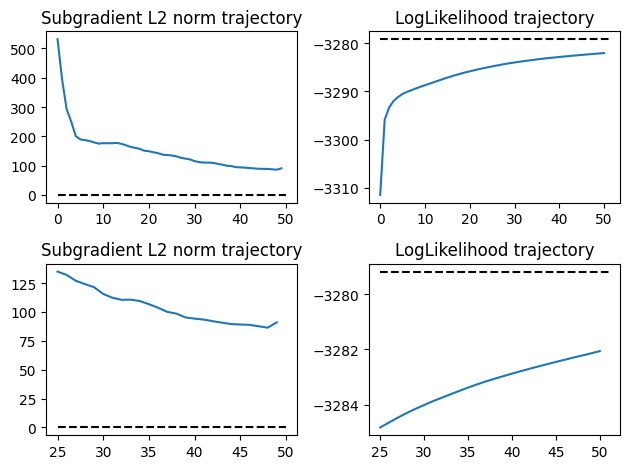

In [ ]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [ ]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

1 0.9733574765533479
-1 -0.8742643265480763
-1.2 -1.185821272180047
-0.1 -0.08674593815586254
-9 -8.929878969487405


### Step function parameters experiment

In [27]:
labels = rd.rand(len(mirlist)) <= logit_scores

In [28]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [29]:
steplengths = np.linspace(0.000005, 0.00005, num=10)
steplengths

array([5.0e-06, 1.0e-05, 1.5e-05, 2.0e-05, 2.5e-05, 3.0e-05, 3.5e-05,
       4.0e-05, 4.5e-05, 5.0e-05])

In [30]:
NITER = 200

In [31]:
# Get the iteration at which logL is hit (speed)
def get_logL__reached_iter(params, true_logL):
    for i, logL in enumerate(params['loglik_trajectory']):
        if logL >= true_logL:
            return i
    return None

In [32]:
# Get the value at the last iteration of the simulation
def get_final_val_avg(params):
    return np.mean(params['loglik_trajectory'][-20:])

In [33]:
pickle_path = "results/simple/step_experiment_simple.pkl"

if os.path.exists(pickle_path):
    with open(pickle_path, "rb") as f:
        saved = pickle.load(f)

    labels = saved["labels"]
    true_logL = saved["true_logL"]
    discrimalign_results_step = saved["discrimalign_results_step"]
    logL_reached_iters = saved["logL_reached_iters"]
    final_vals = saved["final_vals"]

else:
    
    labels = rd.rand(len(mirlist)) <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    
    discrimalign_results_step = []

    logL_reached_iters = []
    final_vals = []

    for stepl in steplengths:
        const_step = create_constant_step(stepl)
        
        params = discrimalign(mirlist, genelist, labels, 
                        stepfunction=const_step,
                        aligner_mode='local',
                        substitution_mode='simple',
                        gap_mode = 'affine',
                        verbose=False, max_iter=NITER,
                        stochastic_factor=0.001,
                        num_threads = 16)
        discrimalign_results_step.append(params)

        logL_reached_iter = get_logL__reached_iter(params, true_logL)
        logL_reached_iters.append(logL_reached_iter if logL_reached_iter is not None else np.inf) # infinity so that they dont show on the scatter plot 

        final_val = get_final_val_avg(params)
        final_vals.append(final_val)

        if logL_reached_iter is not None:
            print(f"step {stepl:.2e}, surpassed logL at iteration {logL_reached_iter} and reached a maximum value of {final_val}")
        else:
            print(f"step {stepl:.2e} did NOT hit logL")
    
    with open(pickle_path, "wb") as f:
        pickle.dump(
            {
                "labels": labels,
                "true_logL": true_logL,
                "discrimalign_results_step": discrimalign_results_step,
                "logL_reached_iters": logL_reached_iters,
                "final_vals": final_vals,
                "steplengths": steplengths,
                "NITER": NITER,
            },
            f
        )

/tmp/ipykernel_38997/3464062125.py:42: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=0.1)


[]

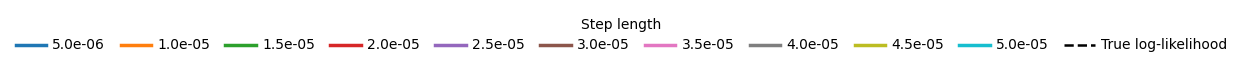

In [34]:
from matplotlib.lines import Line2D

step_colors = plt.cm.tab10(np.linspace(0, 1, len(steplengths)))

legend_handles = [
    Line2D(
        [0], [0],
        color=color,
        lw=2.5,
        label=f"{stepl:.1e}"
    )
    for stepl, color in zip(steplengths, step_colors)
]

legend_handles.append(
    Line2D(
        [0], [0],
        color="k",
        linestyle="--",
        lw=1.8,
        label="True log-likelihood"
    )
)

fig = plt.figure(figsize=(5.5, 0.65))

ax = fig.add_subplot(111)
ax.axis("off")

ax.legend(
    handles=legend_handles,
    title="Step length",
    loc="center",
    ncol=11,
    frameon=False,
    handlelength=2.2,
    columnspacing=1.1,
    handletextpad=0.45,
    borderaxespad=0.0
)

plt.tight_layout(pad=0.1)
plt.savefig("results/step_length_legend.png", dpi=DPI, bbox_inches="tight")
plt.plot()

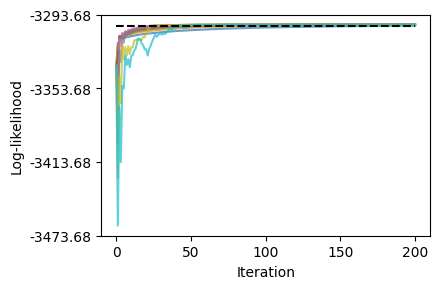

In [35]:

plt.figure(figsize=FIGSIZE)
for params,color in zip(discrimalign_results_step, step_colors):
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')

plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
ax = plt.gca()
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xticks(np.linspace(0, 200, 5, dtype=int))
ax.set_yticks(np.linspace(*ax.get_ylim(), 4))
plt.tight_layout()
plt.savefig("results/simple/step_experiment_full_trajectories_simple.png", dpi=DPI)

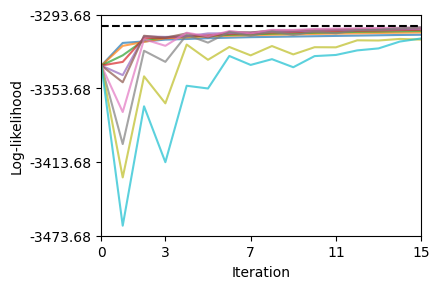

In [36]:
# zoom on start
plt.figure(figsize=FIGSIZE)
for params,color in zip(discrimalign_results_step, step_colors):
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')

plt.xlim(0, 15)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")

ax = plt.gca()

ax.set_xticks(np.linspace(0, 15, 5, dtype=int))
ax.set_yticks(np.linspace(*ax.get_ylim(), 4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig("results/simple/step_experiment_zoom_start_simple.png", dpi=DPI)

In [37]:
# # zoom where most trajectories hit logL
# plt.figure(figsize=FIGSIZE)
# for params,color in zip(discrimalign_results_step, step_colors):
#     plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
# plt.plot([0, NITER], [true_logL, true_logL], 'k--')

# plt.xlim(25, NITER) 
# all_vals = np.concatenate([
#     np.array(p['loglik_trajectory'])[25:]
#     for p in discrimalign_results_step
# ])

# ymin, ymax = all_vals.min(), all_vals.max()
# plt.ylim(ymin, 0.99 * ymax)

# plt.xlabel("Iteration")
# plt.ylabel("Log-likelihood")
# ax = plt.gca()
# ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# plt.tight_layout()
# plt.savefig("results/simple/step_experiment_zoom_mid_simple.png", dpi=DPI)

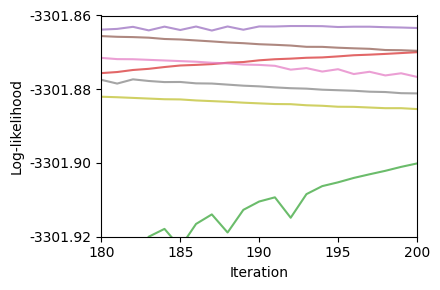

In [38]:
# zoom on the end of the iterations

plt.figure(figsize=FIGSIZE)
for plotid, params,color in zip(range(len(discrimalign_results_step)), discrimalign_results_step, step_colors):
    if plotid == 9: continue
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)

plt.plot([0, NITER], [true_logL, true_logL], 'k--')


plt.xlim(NITER-20, NITER)

# collect only last 20 iterations
all_vals = np.concatenate([
    np.array(p['loglik_trajectory'])[NITER-20:]
    for p in discrimalign_results_step
])

#sort and drop lowest x % 
sorted_vals = np.sort(all_vals)
cutoff = int(0.3 * len(sorted_vals))  # remove lowest x%
trimmed_vals = sorted_vals[cutoff:]

ymin = trimmed_vals.min()
ymax = trimmed_vals.max()

pad = 0.05 * (ymax - ymin)

plt.ylim(ymin, ymax + pad)

ax = plt.gca()
ax.set_xticks(np.linspace(180, 200, 5, dtype=int))
ax.set_yticks(np.linspace(*ax.get_ylim(), 4))

ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))


plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.tight_layout()
plt.savefig("results/simple/step_experiment_zoom_end_simple.png", dpi=DPI)

/tmp/ipykernel_38997/3503067501.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_steps))


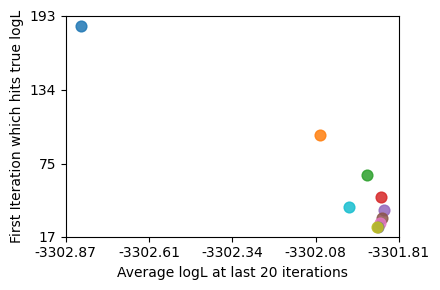

In [39]:
plt.figure(figsize=FIGSIZE)

logL_reached_iters_arr = np.array(logL_reached_iters)
final_vals_arr = np.array(final_vals)
steplengths_arr = np.array(steplengths)

mask = np.isfinite(logL_reached_iters_arr)

# Get unique step sizes
unique_steps = np.sort(np.unique(steplengths_arr[mask]))

# Use a discrete colormap
cmap = plt.cm.get_cmap("tab10", len(unique_steps))

for i, s in enumerate(unique_steps):
    idx = (steplengths_arr == s) & mask

    plt.scatter(
        final_vals_arr[idx],
        logL_reached_iters_arr[idx],
        color=cmap(i),
        s=60,
        label=f"{s:.2e}",
        alpha=0.85
    )

plt.ylabel("First Iteration which hits true logL")
plt.xlabel("Average logL at last 20 iterations")


ax = plt.gca()
xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(xmin, xmax, 5))
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax.set_yticks(np.linspace(*ax.get_ylim(), 4, dtype=int))


plt.tight_layout()
plt.savefig("results/simple/step_experiment_scatter_hit_vs_final_simple.png", dpi=DPI)

### Replicates

In [40]:
REPS = 20 #20
NITER = 200

In [41]:
const_step = create_constant_step(2.0e-05) # choose best step from prev exp 
# const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [42]:
# Checks if the chosen step size is stable in convergence across different datasets
pickle_path = "results/simple/replicates_simple.pkl"

if os.path.exists(pickle_path):
    with open(pickle_path, "rb") as f:
        saved = pickle.load(f)

    discrimalign_results_rep = saved["discrimalign_results_rep"]
    true_logLs = saved["true_logLs"]
    logL_reached_iters_rep = saved["logL_reached_iters_rep"]
    final_vals_rep = saved["final_vals_rep"]

else:

    discrimalign_results_rep = []
    true_logLs = []

    logL_reached_iters_rep = []
    final_vals_rep = []

    for _ in range(REPS):
        labels = rd.rand(len(mirlist)) <= logit_scores
        true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
        true_logLs.append(true_logL)
        params = discrimalign(mirlist, genelist, labels, 
                        stepfunction=const_step,
                        aligner_mode='local',
                        substitution_mode='simple',
                        gap_mode = 'affine',
                        verbose=False, max_iter=NITER,
                        stochastic_factor=0.001,
                        num_threads = 16)
        discrimalign_results_rep.append(params)

        logL_reached_iter = get_logL__reached_iter(params, true_logL)
        
        logL_reached_iters_rep.append(
            logL_reached_iter if logL_reached_iter is not None else np.inf
        )

        final_vals_rep.append(get_final_val_avg(params))

    for i, it in enumerate(logL_reached_iters_rep):
        if np.isfinite(it):
            print(f"rep {i} hit logL at iteration {it}, final={final_vals_rep[i]:.2f}")
        else:
            print(f"rep {i} did NOT hit logL, final={final_vals_rep[i]:.2f}")

    with open(pickle_path, "wb") as f:
        pickle.dump(
            {
                "discrimalign_results_rep": discrimalign_results_rep,
                "true_logLs": true_logLs,
                "logL_reached_iters_rep": logL_reached_iters_rep,
                "final_vals_rep": final_vals_rep,
                "REPS": REPS,
                "NITER": NITER,
            },
            f
        )

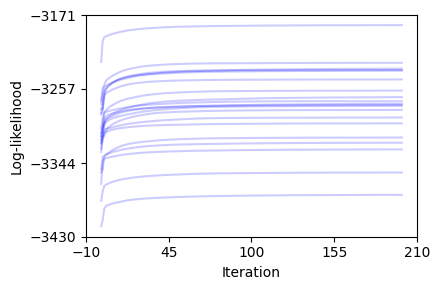

In [43]:
plt.figure(figsize=FIGSIZE)

for params in discrimalign_results_rep:
    plt.plot(
        np.arange(NITER + 1),
        params['loglik_trajectory'],
        alpha=0.2,
        color='b'
    )

plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
ax = plt.gca()
xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(xmin, xmax, 5))
ax.set_xlim(xmin, xmax)

ax.set_yticks(np.linspace(*ax.get_ylim(), 4, dtype=int))

plt.tight_layout()
plt.savefig("results/simple/replicates_loglik_trajectories_simple.png", dpi=DPI)

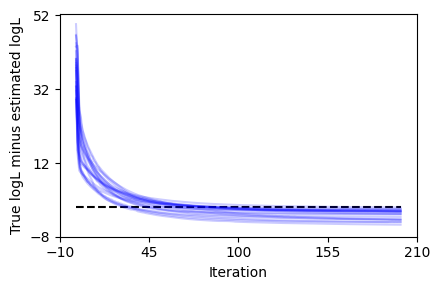

In [44]:
plt.figure(figsize=FIGSIZE)

plt.plot([0, NITER], [0, 0], 'k--')

for params, tlL in zip(discrimalign_results_rep, true_logLs):
    plt.plot(
        np.arange(NITER + 1),
        tlL - np.array(params['loglik_trajectory']),
        alpha=0.2,
        color='b'
    )

plt.xlabel("Iteration")
plt.ylabel("True logL minus estimated logL")

ax = plt.gca()
xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(xmin, xmax, 5))
ax.set_xlim(xmin, xmax)

ax.set_yticks(np.linspace(*ax.get_ylim(), 4, dtype=int))

plt.tight_layout()
plt.savefig("results/simple/replicates_loglik_gap_simple.png", dpi=DPI)